In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.models.evaluator import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
    plot_model_comparison
)
from src.models.reporter import (
    generate_classification_report_dict,
    generate_markdown_report,
    save_markdown_report,
    save_combined_metrics
)
from src.data.priority_labeler import (
    assign_priority_labels,
    PRIORITY_COLUMN
)
from src.utils.config import (
    MODELS_DIR,
    REPORTS_DIR,
    PROCESSED_DATA_DIR,
    CATEGORY_LABELS,
    PRIORITY_LABELS,
    CATEGORY_TARGET
)

sns.set_theme(style="whitegrid")
print("Imports successful")

Imports successful


In [4]:
# Load models
cat_model = joblib.load(MODELS_DIR / "category_classifier.pkl")
pri_model = joblib.load(MODELS_DIR / "priority_classifier.pkl")
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")

# Load splits
splits = joblib.load(MODELS_DIR / "train_test_splits.pkl")
X_test_tfidf = splits["X_test_tfidf"]
X_test_raw   = splits["X_test"]
y_cat_test   = splits["y_cat_test"]

# Load test data for priority labels
test_clean = pd.read_csv(PROCESSED_DATA_DIR / "test_cleaned.csv")
test_priority = assign_priority_labels(test_clean)
y_pri_test = test_priority[PRIORITY_COLUMN].reset_index(drop=True)

print("All artifacts loaded successfully")
print(f"Test set size: {len(y_cat_test)}")

[2026-04-11 11:44:23] INFO — src.data.priority_labeler — Assigning rule-based priority labels...
[2026-04-11 11:44:23] INFO — src.data.priority_labeler — Priority distribution:
[2026-04-11 11:44:23] INFO — src.data.priority_labeler —   High: 270
[2026-04-11 11:44:23] INFO — src.data.priority_labeler —   Medium: 191
[2026-04-11 11:44:23] INFO — src.data.priority_labeler —   Critical: 138
[2026-04-11 11:44:23] INFO — src.data.priority_labeler —   Low: 58
All artifacts loaded successfully
Test set size: 657


[2026-04-11 11:44:23] INFO — src.models.evaluator — Evaluating LinearSVC - Category...
[2026-04-11 11:44:23] INFO — src.models.evaluator —   Accuracy:  0.7839
[2026-04-11 11:44:23] INFO — src.models.evaluator —   Precision: 0.7963
[2026-04-11 11:44:23] INFO — src.models.evaluator —   Recall:    0.7839
[2026-04-11 11:44:23] INFO — src.models.evaluator —   F1 Score:  0.7874

=== CLASSIFICATION REPORT — LinearSVC - Category ===
                   precision    recall  f1-score   support

 Active Directory       0.47      0.51      0.49        49
Computer-Services       0.69      0.61      0.65        41
              EOL       1.00      1.00      1.00        58
      Fileservice       0.96      0.92      0.94       138
             O365       0.60      0.78      0.68        92
         Software       0.69      0.66      0.67        58
  Support general       0.84      0.77      0.80       221

         accuracy                           0.78       657
        macro avg       0.75      0.75

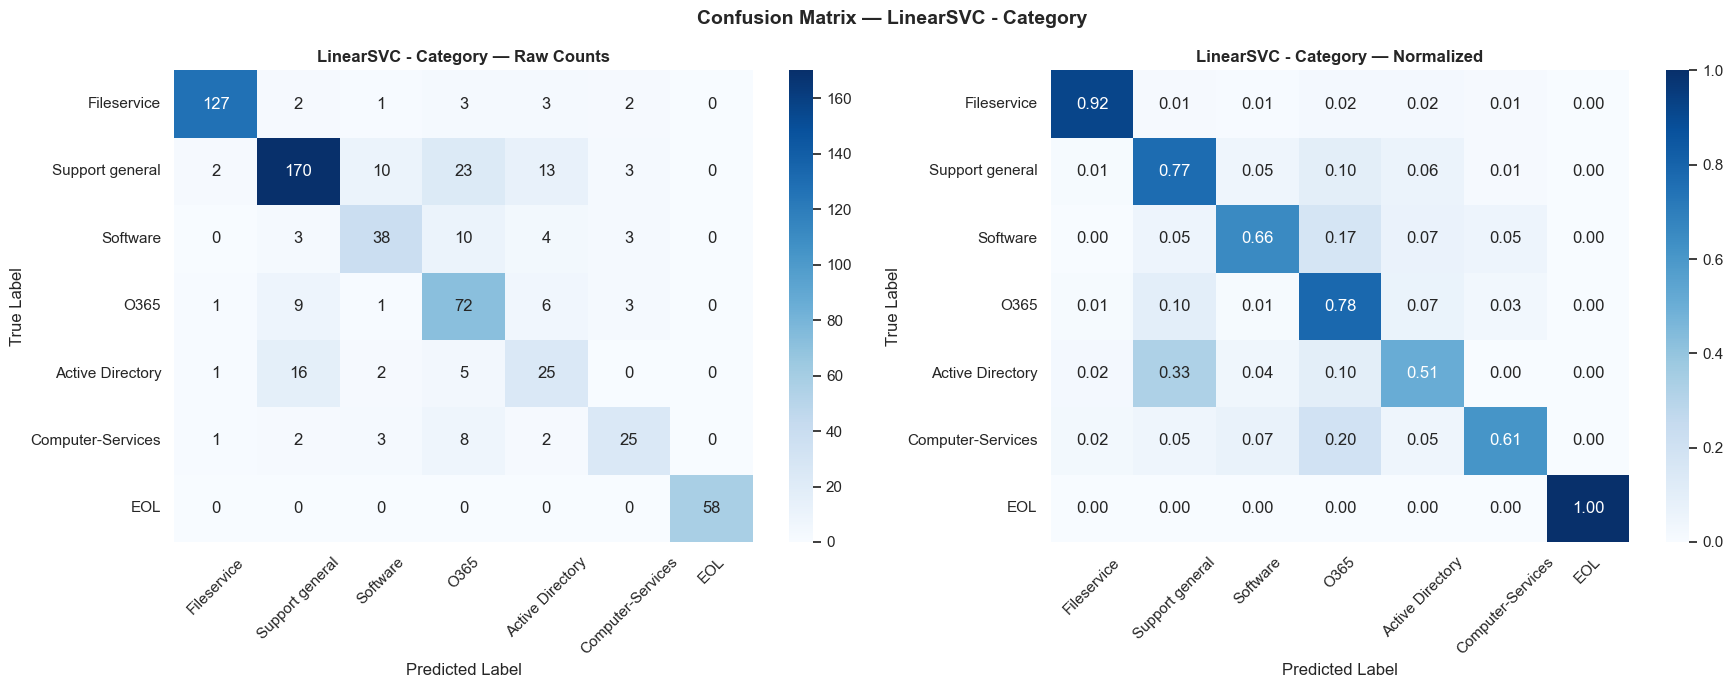

[2026-04-11 11:44:25] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\final_confusion_matrix_category.png


In [5]:
cat_metrics, cat_preds = evaluate_model(
    cat_model, X_test_tfidf, y_cat_test, "LinearSVC - Category"
)

print_classification_report(y_cat_test, cat_preds, "LinearSVC - Category")

plot_confusion_matrix(
    y_cat_test, cat_preds,
    "LinearSVC - Category",
    CATEGORY_LABELS,
    "final_confusion_matrix_category.png"
)

[2026-04-11 11:44:25] INFO — src.models.evaluator — Evaluating LinearSVC - Priority...
[2026-04-11 11:44:25] INFO — src.models.evaluator —   Accuracy:  0.8676
[2026-04-11 11:44:25] INFO — src.models.evaluator —   Precision: 0.8678
[2026-04-11 11:44:25] INFO — src.models.evaluator —   Recall:    0.8676
[2026-04-11 11:44:25] INFO — src.models.evaluator —   F1 Score:  0.8676

=== CLASSIFICATION REPORT — LinearSVC - Priority ===
              precision    recall  f1-score   support

    Critical       0.96      0.93      0.95       138
        High       0.84      0.87      0.86       270
         Low       1.00      1.00      1.00        58
      Medium       0.80      0.78      0.79       191

    accuracy                           0.87       657
   macro avg       0.90      0.90      0.90       657
weighted avg       0.87      0.87      0.87       657



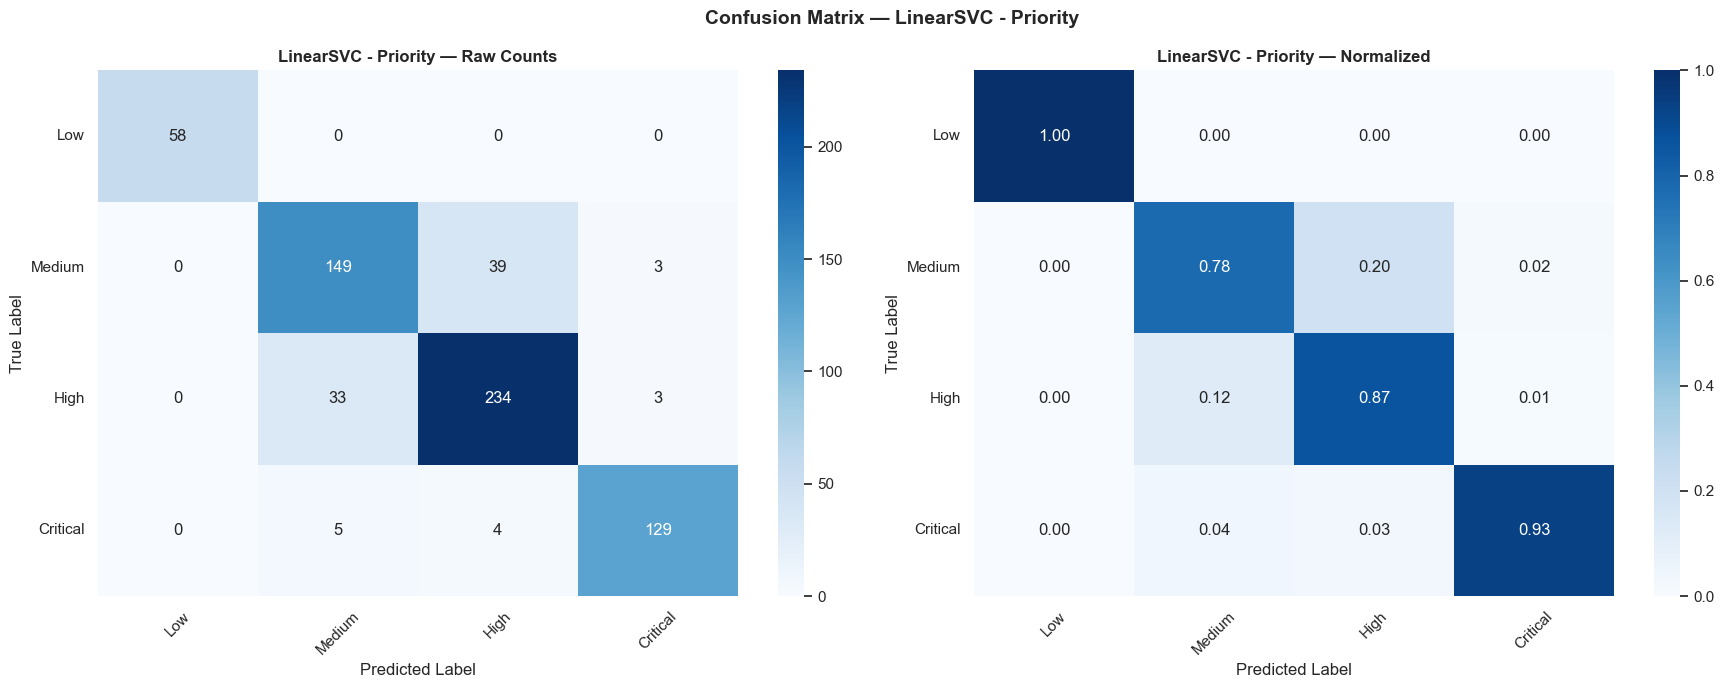

[2026-04-11 11:44:26] INFO — src.models.evaluator — Confusion matrix saved to E:\Future ml projects\FUTURE_ML_02\outputs\figures\final_confusion_matrix_priority.png


In [6]:
pri_metrics, pri_preds = evaluate_model(
    pri_model, X_test_tfidf, y_pri_test, "LinearSVC - Priority"
)

print_classification_report(y_pri_test, pri_preds, "LinearSVC - Priority")

plot_confusion_matrix(
    y_pri_test, pri_preds,
    "LinearSVC - Priority",
    PRIORITY_LABELS,
    "final_confusion_matrix_priority.png"
)

In [7]:
cat_report_dict = generate_classification_report_dict(
    y_cat_test, cat_preds, "category"
)

print("=== PER CLASS BREAKDOWN - CATEGORY ===\n")
print(f"{'Category':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 65)

skip = {"accuracy", "macro avg", "weighted avg"}
for label, scores in cat_report_dict.items():
    if label in skip:
        continue
    if isinstance(scores, dict):
        print(
            f"{label:<25} "
            f"{scores['precision']:>10.3f} "
            f"{scores['recall']:>10.3f} "
            f"{scores['f1-score']:>10.3f} "
            f"{int(scores['support']):>10}"
        )

=== PER CLASS BREAKDOWN - CATEGORY ===

Category                   Precision     Recall         F1    Support
-----------------------------------------------------------------
Active Directory               0.472      0.510      0.490         49
Computer-Services              0.694      0.610      0.649         41
EOL                            1.000      1.000      1.000         58
Fileservice                    0.962      0.920      0.941        138
O365                           0.595      0.783      0.676         92
Software                       0.691      0.655      0.673         58
Support general                0.842      0.769      0.804        221


In [8]:
pri_report_dict = generate_classification_report_dict(
    y_pri_test, pri_preds, "priority"
)

print("=== PER CLASS BREAKDOWN - PRIORITY ===\n")
print(f"{'Priority':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 55)

for label, scores in pri_report_dict.items():
    if label in skip:
        continue
    if isinstance(scores, dict):
        print(
            f"{label:<15} "
            f"{scores['precision']:>10.3f} "
            f"{scores['recall']:>10.3f} "
            f"{scores['f1-score']:>10.3f} "
            f"{int(scores['support']):>10}"
        )

=== PER CLASS BREAKDOWN - PRIORITY ===

Priority         Precision     Recall         F1    Support
-------------------------------------------------------
Critical             0.956      0.935      0.945        138
High                 0.845      0.867      0.856        270
Low                  1.000      1.000      1.000         58
Medium               0.797      0.780      0.788        191


In [9]:
summary = pd.DataFrame([
    {
        "Task":     "Category Classification",
        "Model":    "LinearSVC",
        "Classes":  7,
        "Accuracy": cat_metrics["accuracy"],
        "F1":       cat_metrics["f1_score"],
    },
    {
        "Task":     "Priority Prediction",
        "Model":    "LinearSVC",
        "Classes":  4,
        "Accuracy": pri_metrics["accuracy"],
        "F1":       pri_metrics["f1_score"],
    }
])

print("=== FINAL SYSTEM SUMMARY ===")
print(summary.to_string(index=False))

=== FINAL SYSTEM SUMMARY ===
                   Task     Model  Classes  Accuracy     F1
Category Classification LinearSVC        7    0.7839 0.7874
    Priority Prediction LinearSVC        4    0.8676 0.8676


In [10]:
from src.data.preprocessor import clean_text

print("=== LIVE PREDICTIONS ON UNSEEN TICKETS ===\n")

sample_indices = [0, 50, 100, 200, 300, 400, 500]

print(f"{'Ticket Text':<45} {'True Cat':<20} {'Pred Cat':<20} {'Priority'}")
print("-" * 105)

for idx in sample_indices:
    raw_text  = str(X_test_raw.iloc[idx])
    true_cat  = y_cat_test.iloc[idx]
    cleaned   = clean_text(raw_text)
    features  = vectorizer.transform([cleaned])
    pred_cat  = cat_model.predict(features)[0]
    pred_pri  = pri_model.predict(features)[0]
    match     = "✓" if pred_cat == true_cat else "✗"

    print(
        f"{raw_text[:43]:<45} ",
        f"{true_cat:<20} ",
        f"{pred_cat:<20} ",
        f"{pred_pri}  {match}"
    )

=== LIVE PREDICTIONS ON UNSEEN TICKETS ===

Ticket Text                                   True Cat             Pred Cat             Priority
---------------------------------------------------------------------------------------------------------
[TICKET ID] - New Support Ticket received      Support general       Software              Medium  ✗
[TICKET ID] - New Support Ticket received      Fileservice           Fileservice           Critical  ✓
[TICKET ID] - New Support Ticket received      Computer-Services     Computer-Services     Medium  ✓
Light User for external - [TICKET ID] - [NA    Support general       Support general       High  ✓
[TICKET ID] - New information received on c    Support general       Support general       High  ✓
The following system must be set to End Of     EOL                   EOL                   Low  ✓
[TICKET ID] - New Support Ticket received      Software              Software              High  ✓


In [11]:
report_md = generate_markdown_report(
    category_metrics=cat_metrics,
    priority_metrics=pri_metrics,
    category_report=cat_report_dict,
    priority_report=pri_report_dict,
    category_model_name="LinearSVC",
    priority_model_name="LinearSVC",
)

save_markdown_report(report_md, "final_report.md")
save_combined_metrics(cat_metrics, pri_metrics, "combined_metrics.json")

print("=== REPORT SAVED ===")
print("Location: outputs/reports/final_report.md")
print("Metrics:  outputs/reports/combined_metrics.json")

[2026-04-11 11:44:29] INFO — src.models.reporter — Markdown report saved to E:\Future ml projects\FUTURE_ML_02\outputs\reports\final_report.md
[2026-04-11 11:44:29] INFO — src.models.reporter — Combined metrics saved to E:\Future ml projects\FUTURE_ML_02\outputs\reports\combined_metrics.json
=== REPORT SAVED ===
Location: outputs/reports/final_report.md
Metrics:  outputs/reports/combined_metrics.json


In [12]:
import os

print("=== OUTPUT FILES VERIFICATION ===\n")

figures = [
    "category_distribution.png",
    "priority_distribution.png",
    "top_features_per_category.png",
    "text_length_before_after.png",
    "category_model_comparison.png",
    "priority_model_comparison.png",
    "final_confusion_matrix_category.png",
    "final_confusion_matrix_priority.png",
]

models = [
    "tfidf_vectorizer.pkl",
    "category_classifier.pkl",
    "priority_classifier.pkl",
    "train_test_splits.pkl",
]

reports = [
    "final_report.md",
    "combined_metrics.json",
    "category_metrics.json",
    "priority_metrics.json",
]

def check_files(folder, files):
    for f in files:
        path = folder / f
        status = "✅" if path.exists() else "❌ MISSING"
        print(f"  {status}  {f}")

from src.utils.config import FIGURES_DIR, MODELS_DIR, REPORTS_DIR

print("Figures:")
check_files(FIGURES_DIR, figures)

print("\nModels:")
check_files(MODELS_DIR, models)

print("\nReports:")
check_files(REPORTS_DIR, reports)

=== OUTPUT FILES VERIFICATION ===

Figures:
  ✅  category_distribution.png
  ✅  priority_distribution.png
  ✅  top_features_per_category.png
  ✅  text_length_before_after.png
  ✅  category_model_comparison.png
  ❌ MISSING  priority_model_comparison.png
  ✅  final_confusion_matrix_category.png
  ✅  final_confusion_matrix_priority.png

Models:
  ✅  tfidf_vectorizer.pkl
  ✅  category_classifier.pkl
  ✅  priority_classifier.pkl
  ✅  train_test_splits.pkl

Reports:
  ✅  final_report.md
  ✅  combined_metrics.json
  ✅  category_metrics.json
  ❌ MISSING  priority_metrics.json
